# 2.2 Нейроморфные вычисления

Задание: **Вариант 4. Сравнение моделей нейронов**

Реализуйте три класса нейронов: LIFNeuron, IzhikevichNeuron и SimpleIntegrateNeuron. Для каждого класса реализуйте метод step с соответствующими уравнениями. Сравните их реакцию на один и тот же входной ток (ступенька, импульс, синусоида). Постройте графики мембранного потенциала и спайковой активности для всех трех моделей.

---

In [9]:
import numpy as np
import matplotlib.pyplot as plt

class SimpleIntegrateNeuron:
    def __init__(self, dt=0.1, tau=10.0, V_rest=0.0, V_thresh=1.0):
        self.dt = dt
        self.tau = tau
        self.V_rest = V_rest
        self.V_thresh = V_thresh
        self.V = V_rest
    
    def step(self, I):
        dV = (-(self.V - self.V_rest) + I) * (self.dt / self.tau)
        self.V += dV
        spike = self.V >= self.V_thresh
        if spike:
            self.V = self.V_rest
        return self.V, spike


class LIFNeuron:
    def __init__(self, dt=0.1, tau=20.0, V_rest=-65.0, V_thresh=-50.0, R=1.0):
        self.dt = dt
        self.tau = tau
        self.V = V_rest
        self.V_rest = V_rest
        self.V_thresh = V_thresh
        self.R = R
    
    def step(self, I):
        dV = (-(self.V - self.V_rest) + self.R * I) * (self.dt / self.tau)
        self.V += dV
        spike = self.V >= self.V_thresh
        if spike:
            self.V = self.V_rest
        return self.V, spike


class IzhikevichNeuron:
    def __init__(self, dt=0.1, a=0.02, b=0.2, c=-65, d=6, V=-65, u=None):
        self.dt = dt
        self.a = a
        self.b = b
        self.c = c
        self.d = d
        self.V = V
        self.u = u if u is not None else b * V
    
    def step(self, I):
        spike = False
        if self.V >= 30:
            self.V = self.c
            self.u += self.d
            spike = True
        dV = (0.04 * self.V**2 + 5 * self.V + 140 - self.u + I) * self.dt
        du = (self.a * (self.b * self.V - self.u)) * self.dt
        self.V += dV
        self.u += du
        return self.V, spike

In [10]:
T = 200
dt = 0.1
time = np.arange(0, T, dt)

I_step = np.zeros_like(time)
I_step[500:1500] = 10           # ступенька

I_pulse = np.zeros_like(time)
I_pulse[500:510] = 15           # короткий импульс

I_sin = 5 * np.sin(0.1 * time)  # синусоида

currents = {'Ступенька': I_step, 'Импульс': I_pulse, 'Синусоида': I_sin}

def simulate_neuron(neuron_class, I_input):
    neuron = neuron_class(dt=dt)
    V_trace, spike_trace = [], []
    for I in I_input:
        v, s = neuron.step(I)
        V_trace.append(v)
        spike_trace.append(s)
    return np.array(V_trace), np.array(spike_trace)

results = {}
for current_name, I_input in currents.items():
    results[current_name] = {}
    results[current_name]['Простой'] = simulate_neuron(SimpleIntegrateNeuron, I_input)
    results[current_name]['LIF'] = simulate_neuron(LIFNeuron, I_input)
    results[current_name]['Izhikevich'] = simulate_neuron(IzhikevichNeuron, I_input)

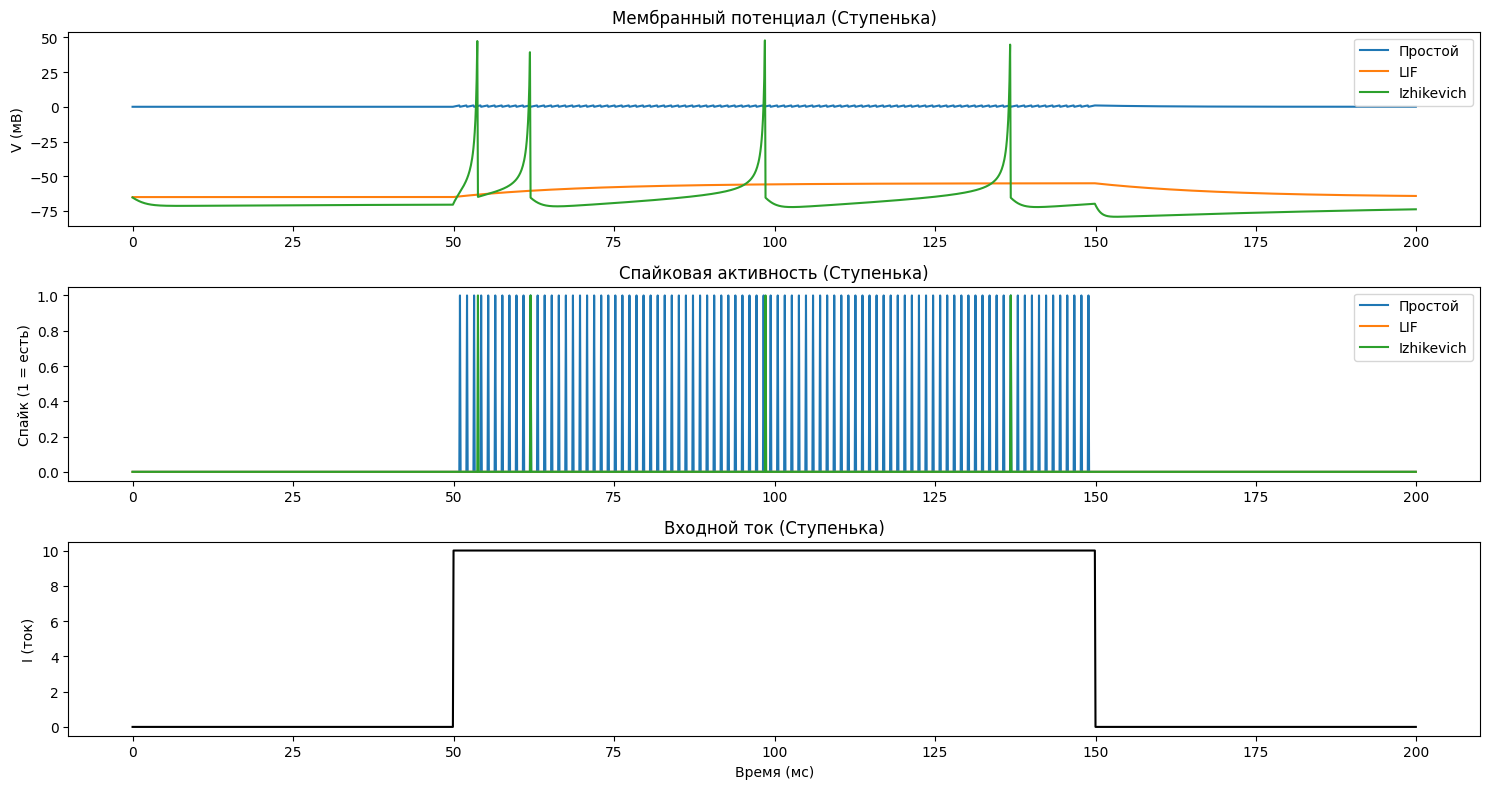

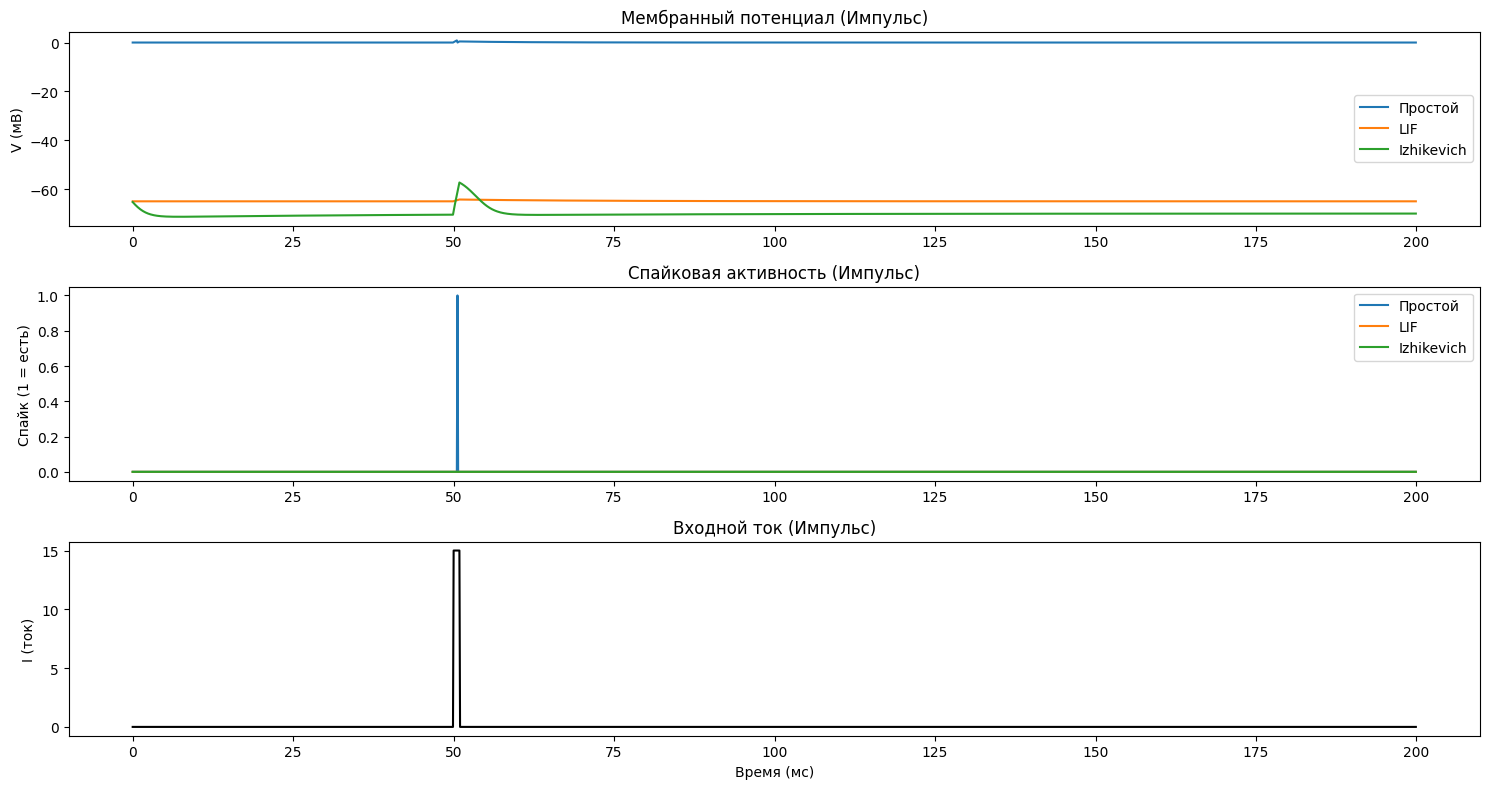

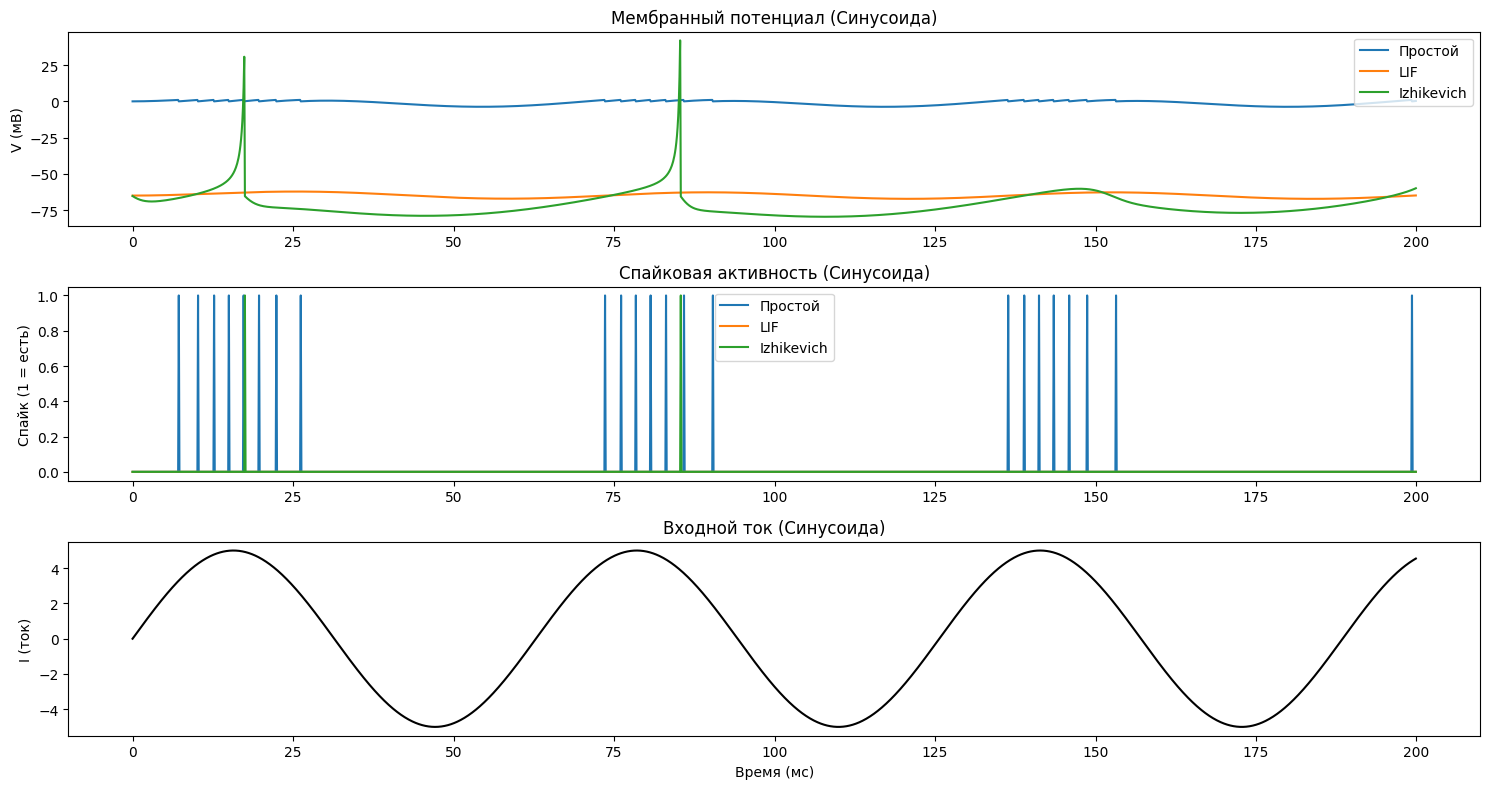

In [12]:
for current_name in currents.keys():
    plt.figure(figsize=(15, 8))
    
    # Мембранный потенциал
    plt.subplot(3,1,1)
    for key in ['Простой', 'LIF', 'Izhikevich']:
        plt.plot(time, results[current_name][key][0], label=key)
    plt.title(f'Мембранный потенциал ({current_name})')
    plt.ylabel('V (мВ)')
    plt.legend()
    
    # Спайки
    plt.subplot(3,1,2)
    for key in ['Простой', 'LIF', 'Izhikevich']:
        plt.plot(time, results[current_name][key][1], label=key)
    plt.title(f'Спайковая активность ({current_name})')
    plt.ylabel('Спайк (1 = есть)')
    plt.legend()
    
    # Входной ток
    plt.subplot(3,1,3)
    plt.plot(time, currents[current_name], 'k')
    plt.title(f'Входной ток ({current_name})')
    plt.ylabel('I (ток)')
    plt.xlabel('Время (мс)')
    
    plt.tight_layout()
    plt.show()